# Лабораторная работа: Генеративные модели классификации (LDA и Naive Bayes)

## Общая цель работы
Изучить генеративный подход к классификации на примере двух моделей: **Линейный дискриминантный анализ (LDA)** и **Наивный байесовский классификатор (NB)**. Вы не просто реализуете алгоритмы, а исследуете, как предположения о структуре данных (ковариация, независимость признаков) влияют на разделяющую поверхность и качество классификации.

---

## Теоретическое введение (обязательно к прочтению)

### Генеративный vs дискриминативный подход
- **Дискриминативные модели** (логистическая регрессия, SVM) моделируют границу между классами напрямую: $ p(y|x) $.
- **Генеративные модели** моделируют совместное распределение $ p(x, y) = p(x|y) \cdot p(y) $, а затем через теорему Байеса получают $ p(y|x) $.

### Байесовский классификатор
Для задачи классификации с $ K $ классами:
$
\hat{y} = \arg\max_{y} p(y|x) = \arg\max_{y} \frac{p(x|y) \cdot p(y)}{p(x)} = \arg\max_{y} p(x|y) \cdot p(y)
$

Где:
- $ p(y) $ — **априорная вероятность** класса (оценивается как доля объектов класса в выборке).
- $ p(x|y) $ — **правдоподобие** (likelihood) — вероятность наблюдать объект $ x $ в классе $ y $.

### Два подхода к моделированию правдоподобия

**1. LDA (Линейный дискриминантный анализ)**
- Предполагает, что $ p(x|y) $ — многомерное нормальное распределение.
- **Ключевое допущение:** матрицы ковариации для всех классов **одинаковы**: $ C_0 = C_1 = ... = C $.
- **Следствие:** разделяющая поверхность между классами является **линейной** (гиперплоскостью).
- Параметры для каждого класса: $ \mu_y $ (среднее) и общая $ C $.

**2. Наивный байесовский классификатор (NB)**
- Также предполагает нормальное распределение $ p(x|y) $, но **без учета корреляций** между признаками.
- **Ключевое допущение:** признаки условно независимы при заданном классе:
  $
  p(x_1, x_2, ..., x_n|y) = \prod_{i=1}^{n} p(x_i|y)
  $
- **Следствие:** матрица ковариации для каждого класса **диагональная** (все внедиагональные элементы = 0).
- Параметры для каждого класса: $ \mu_y $ и $ \sigma_{y,i}^2 $ (дисперсия каждого признака отдельно).

**Важно:** LDA и NB — частные случаи одного и того же байесовского подхода, различающиеся структурой ковариационной матрицы:
- LDA: одна полная матрица ковариации $ C $ для всех классов.
- NB: отдельная диагональная матрица для каждого класса.

---

## Часть 1. Исследование многомерного нормального распределения (10 баллов)

### 1.1 Генерация данных с заданной ковариацией
**Цель:** научиться генерировать данные с контролируемой структурой зависимости.

1. Создайте $ M = 500 $ точек в двумерном пространстве:
   - Сгенерируйте два независимых вектора: $ x_1 \sim \mathcal{N}(0, \sigma_1^2) $, $ x_2 \sim \mathcal{N}(0, \sigma_2^2) $, где $ \sigma_1 = 0.3 $, $ \sigma_2 = 0.8 $.
2. Примените матрицу поворота на угол $ \alpha = 30^\circ $:
   $
   R = \begin{bmatrix} \cos\alpha & -\sin\alpha \\ \sin\alpha & \cos\alpha \end{bmatrix}
   $
3. Выведите на экран **выборочную матрицу ковариации** (через `np.cov`).
4. Сравните с теоретической: $ C_{теор} = R \cdot \text{diag}(\sigma_1^2, \sigma_2^2) \cdot R^T $.

**Визуализация:**
- Постройте scatter plot полученных точек.
- На том же графике (используя `plt.contour`) нарисуйте эллипсы равной плотности для теоретического распределения (на уровнях 0.5, 1, 2 стандартных отклонения).

**Автопроверка:**
```python
# Проверка: размерность и наличие поворота
assert X.shape == (M, 2), "Неверная размерность данных"
assert np.abs(np.cov(X.T)[0, 1]) > 0.1, "Корреляция слишком мала (проверьте поворот)"
assert np.allclose(np.mean(X, axis=0), 0, atol=0.1), "Среднее должно быть около 0"
```

### 1.2 Сравнение с встроенной функцией
- Сгенерируйте точки с помощью `np.random.multivariate_normal` с той же матрицей ковариации.
- Нарисуйте оба облака точек на одном графике разными цветами.
- **Вопрос (ответить текстом в Markdown):** совпадают ли облака визуально? Почему встроенная функция может быть предпочтительнее?

---

## Часть 2. Визуализация плотности вероятности (5 баллов)

**Цель:** научиться вычислять и визуализировать PDF многомерного нормального распределения.

1. По данным из пункта 1.1 оцените $ \hat{\mu} $ и $ \hat{C} $ (выборочные).
2. Создайте сетку точек в диапазоне от -2 до 2 по обеим осям.
3. Вычислите плотность вероятности в каждой точке сетки **двумя способами**:
   - С помощью `scipy.stats.multivariate_normal(mean=mu, cov=C).pdf()`.
   - Самостоятельно по формуле (1) из задания (используйте `np.linalg.det` и `np.linalg.inv`).
4. Сравните результаты (максимальная разница должна быть < 1e-10).

**Визуализация:**
- Постройте contour plot с заливкой (используя `plt.contourf`).
- Добавьте линии уровня (contour) с подписями значений.
- Нанесите исходные точки поверх фона.

**Автопроверка:**
```python
# Проверка ручного вычисления
pdf_manual = ... # ваша реализация
pdf_scipy = m.pdf(grid_points)
assert np.allclose(pdf_manual, pdf_scipy, atol=1e-8), "Ручное вычисление отличается от scipy"
```

---

## Часть 3. Бинарная классификация через байесовский подход (15 баллов)

**Цель:** визуализировать разделяющую поверхность для двух классов.

### 3.1 Генерация датасета
Создайте два класса (по 300 точек каждый):
- **Класс 0:** $ \mu_0 = (-0.5, 0.5) $, $ C_0 = \begin{bmatrix} 0.2 & 0.1 \\ 0.1 & 0.3 \end{bmatrix} $
- **Класс 1:** $ \mu_1 = (0.5, -0.5) $, $ C_1 = \begin{bmatrix} 0.3 & -0.1 \\ -0.1 & 0.2 \end{bmatrix} $

### 3.2 Визуализация апостериорной вероятности
Для каждой точки сетки вычислите:
$
\Delta(x) = p(x|y=0) \cdot p(y=0) - p(x|y=1) \cdot p(y=1)
$
где $ p(y) $ оценивается как доля объектов класса в выборке.

**Визуализация:**
- Scatter plot точек классов (разными цветами).
- Заливка фона: положительные значения $ \Delta $ — одним цветом (например, синим), отрицательные — другим (красным).
- Линия, где $ \Delta(x) = 0 $ (разделяющая поверхность) — через `plt.contour(..., levels=[0])`.

**Вопрос (ответить текстом):** является ли разделяющая поверхность линейной? Почему?

---

## Часть 4. Линейный дискриминантный анализ (LDA) (20 баллов)

### 4.1 Теоретический вывод (в тетради)
**Задание:** выведите явное выражение для разделяющей поверхности в случае, когда $ C_0 = C_1 = C $. Покажите, что она линейна. Напишите формулу для весов $ w $ и порога $ b $ в уравнении $ w^T x + b = 0 $.

### 4.2 Реализация класса LDA
Реализуйте класс `MyLDA`, следуя шаблону:

```python
from sklearn.base import BaseEstimator
import numpy as np

class MyLDA(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None      # словарь {class: mean_vector}
        self.priors_ = None     # словарь {class: prior_prob}
        self.cov_ = None        # общая ковариационная матрица (2D массив)
        self.coef_ = None       # вектор весов w
        self.intercept_ = None  # порог b
    
    def fit(self, X, y):
        """
        X: np.array, shape (n_samples, n_features)
        y: np.array, shape (n_samples,)
        """
        # 1. Сохранить уникальные классы
        # 2. Для каждого класса: вычислить mean и prior
        # 3. Вычислить общую ковариационную матрицу (усредненную по классам)
        # 4. Вычислить w и b
        pass
    
    def predict(self, X):
        """Возвращает предсказанные классы для X"""
        pass
    
    def predict_proba(self, X):
        """Возвращает вероятности принадлежности к каждому классу"""
        pass
```

**Указания:**
- Для устойчивости добавьте небольшой регуляризатор к ковариационной матрице: `cov_reg = cov + 1e-6 * np.eye(n_features)`.
- Формула для весов для бинарного случая:
  $
  w = C^{-1} (\mu_1 - \mu_0)
  $
  $
  b = -\frac{1}{2} \mu_0^T C^{-1} \mu_0 + \frac{1}{2} \mu_1^T C^{-1} \mu_1 + \log\frac{p(y=1)}{p(y=0)}
  $

### 4.3 Проверка на синтетике
- Создайте два класса с одинаковой ковариацией $ C = \begin{bmatrix} 1 & 0.5 \\ 0.5 & 1 \end{bmatrix} $, но разными средними.
- Обучите ваш `MyLDA` и сравните предсказания с `sklearn.discriminant_analysis.LinearDiscriminantAnalysis`.
- Визуализируйте разделяющую прямую и точки.

**Автопроверка:**
```python
# Сравнение с sklearn
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
sk_lda = LinearDiscriminantAnalysis().fit(X_train, y_train)
my_lda = MyLDA().fit(X_train, y_train)
assert np.allclose(my_lda.predict(X_test), sk_lda.predict(X_test)), "Предсказания не совпадают"
assert np.abs(my_lda.coef_ @ sk_lda.coef_ - 1) < 1e-6, "Вектора весов сонаправлены, но разной длины"
```

---

## Часть 5. Наивный байесовский классификатор (NB) (20 баллов)

### 5.1 Теоретическое обоснование
**Вопрос:** почему в наивном байесе матрица ковариации диагональная? Как это упрощает вычисление $ p(x|y) $?

### 5.2 Реализация класса NB
Реализуйте класс `MyNB`:

```python
class MyNB(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None      # dict {class: mean_vector}
        self.vars_ = None       # dict {class: variance_vector} (диагональ ковариации)
        self.priors_ = None     # dict {class: prior_prob}
    
    def fit(self, X, y):
        """
        Для каждого класса:
        - Вычислить среднее по каждому признаку
        - Вычислить дисперсию по каждому признаку
        - Вычислить априорную вероятность
        """
        pass
    
    def predict(self, X):
        """Вычисляет логарифм правдоподобия для каждого класса и выбирает максимум"""
        pass
```

**Важно:** используйте **логарифмическое правдоподобие** для численной устойчивости:
$
\log p(y|x) \propto \log p(y) + \sum_i \log p(x_i|y) = \log p(y) - \frac{1}{2}\sum_i \left( \log(2\pi\sigma_{y,i}^2) + \frac{(x_i - \mu_{y,i})^2}{\sigma_{y,i}^2} \right)
$

### 5.3 Сравнение с sklearn
- Сравните ваш `MyNB` с `sklearn.naive_bayes.GaussianNB` на тех же данных.
- Убедитесь, что предсказания совпадают (с точностью до численных погрешностей).

**Автопроверка:**
```python
from sklearn.naive_bayes import GaussianNB
sk_nb = GaussianNB().fit(X_train, y_train)
my_nb = MyNB().fit(X_train, y_train)
assert np.allclose(my_nb.predict(X_test), sk_nb.predict(X_test)), "Предсказания NB не совпадают"
```

---

## Часть 6. Экспериментальное сравнение LDA и NB (15 баллов)

### 6.1 Генерация датасетов с разной структурой
Создайте **три** различных датасета для бинарной классификации:

1. **Датасет A (LDA-оптимальный):** классы имеют одинаковую ковариацию, но разные средние.
2. **Датасет B (NB-оптимальный):** признаки независимы внутри каждого класса, но ковариации классов разные.
3. **Датасет C (сложный):** признаки коррелированы, ковариации классов разные.

Используйте `sklearn.datasets.make_classification` с параметрами:
- `n_features=10` (для проверки многомерности)
- `n_informative=5`, `n_redundant=2`
- Для датасета C: `flip_y=0.05` (немного шума).

### 6.2 Сравнение моделей
Для каждого датасета:
1. Разделите на train/test (80/20).
2. Обучите `MyLDA`, `MyNB`, а также (для бенчмарка) `sklearn.linear_model.LogisticRegression`.
3. Посчитайте метрики: **Accuracy**, **Precision**, **Recall**, **F1-score** (для каждого класса отдельно и macro-усредненные).
4. Постройте confusion matrix для каждой модели.

### 6.3 Анализ результатов
В Markdown-ячейке напишите **развернутый вывод**:
- На каком датасете LDA превосходит NB? Почему?
- На каком датасете NB работает лучше? Почему?
- Как влияет размерность пространства на обе модели?
- Когда обе модели падают (датасет C) — почему?

**Визуализация:** для каждого датасета постройте столбчатую диаграмму сравнения метрик.

---

## Критерии оценки (максимум 85 баллов)

| Часть | Баллы | Что проверяется |
|-------|-------|-----------------|
| 1.1 Генерация и поворот | 5 | Корректная генерация, визуализация, сравнение ковариаций |
| 1.2 Сравнение с `multivariate_normal` | 5 | Понимание способов генерации |
| 2. PDF и визуализация | 5 | Ручное вычисление, сравнение со scipy |
| 3. Бинарная классификация | 10 | Правильная визуализация Δ и разделяющей поверхности |
| 4.1 Теоретический вывод LDA | 5 | Формулы для w и b |
| 4.2 Реализация MyLDA | 10 | Код, совместимость со sklearn API |
| 4.3 Проверка на синтетике | 5 | Сравнение с sklearn, визуализация |
| 5.1 Теория NB | 5 | Понимание условной независимости |
| 5.2 Реализация MyNB | 10 | Код, логарифмическое правдоподобие |
| 5.3 Проверка с sklearn | 5 | Совпадение предсказаний |
| 6.1 Генерация 3 датасетов | 5 | Разнообразие структур |
| 6.2 Эксперименты и метрики | 10 | Все метрики, confusion matrix |
| 6.3 Анализ и выводы | 10 | Глубокий анализ результатов |
| **Стиль кода и оформление** | **Бонус +5** | Чистый код, комментарии, структура ноутбука |

---

## Полезные функции и материалы

### Генерация датасета с заданной ковариацией
```python
def generate_gaussian_class(mean, cov, n_samples=300):
    return np.random.multivariate_normal(mean, cov, n_samples)

# Пример создания двух классов
X0 = generate_gaussian_class(mean0, cov0, 300)
X1 = generate_gaussian_class(mean1, cov1, 300)
X = np.vstack([X0, X1])
y = np.hstack([np.zeros(300), np.ones(300)])
```

### Вычисление разделяющей поверхности
```python
def decision_function(X, means, cov, priors):
    """Возвращает разность логарифмов апостериорных вероятностей"""
    log_p0 = np.log(priors[0]) + multivariate_normal(means[0], cov).logpdf(X)
    log_p1 = np.log(priors[1]) + multivariate_normal(means[1], cov).logpdf(X)
    return log_p1 - log_p0  # >0 => класс 1, <0 => класс 0
```

---

## Рекомендации по оформлению

1. Каждая часть должна быть отдельным разделом с заголовком.
2. Код должен быть прокомментирован (на русском или английском).
3. Все графики должны иметь подписи осей и легенды.
4. В конце каждой части — краткий вывод (1-2 предложения).
5. Итоговый вывод — развернутый (10+ предложений) с ответами на все поставленные вопросы.

---

Это задание теперь требует не только написания кода, но и **понимания теории** через визуализацию и эксперименты. Все блоки с проверками помогут студентам самостоятельно убедиться в корректности решения, а преподавателю — быстро оценить работу.

## Часть 1. Исследование многомерного нормального распределения (10 баллов)

### 1.1 Генерация данных с заданной ковариацией
**Цель:** научиться генерировать данные с контролируемой структурой зависимости.

1. Создайте $ M = 500 $ точек в двумерном пространстве:
   - Сгенерируйте два независимых вектора: $ x_1 \sim \mathcal{N}(0, \sigma_1^2) $, $ x_2 \sim \mathcal{N}(0, \sigma_2^2) $, где $ \sigma_1 = 0.3 $, $ \sigma_2 = 0.8 $.
2. Примените матрицу поворота на угол $ \alpha = 30^\circ $:
   $
   R = \begin{bmatrix} \cos\alpha & -\sin\alpha \\ \sin\alpha & \cos\alpha \end{bmatrix}
   $
3. Выведите на экран **выборочную матрицу ковариации** (через `np.cov`).
4. Сравните с теоретической: $ C_{теор} = R \cdot \text{diag}(\sigma_1^2, \sigma_2^2) \cdot R^T $.

**Визуализация:**
- Постройте scatter plot полученных точек.
- На том же графике (используя `plt.contour`) нарисуйте эллипсы равной плотности для теоретического распределения (на уровнях 0.5, 1, 2 стандартных отклонения).

**Автопроверка:**
```python
# Проверка: размерность и наличие поворота
assert X.shape == (M, 2), "Неверная размерность данных"
assert np.abs(np.cov(X.T)[0, 1]) > 0.1, "Корреляция слишком мала (проверьте поворот)"
assert np.allclose(np.mean(X, axis=0), 0, atol=0.1), "Среднее должно быть около 0"
```

### 1.2 Сравнение с встроенной функцией
- Сгенерируйте точки с помощью `np.random.multivariate_normal` с той же матрицей ковариации.
- Нарисуйте оба облака точек на одном графике разными цветами.
- **Вопрос (ответить текстом в Markdown):** совпадают ли облака визуально? Почему встроенная функция может быть предпочтительнее?

---

Теоретическая матрица ковариации [[ 0.2275     -0.23815699]
 [-0.23815699  0.5025    ]]
Выборочная матрица ковариации [[ 0.23350568 -0.23857906]
 [-0.23857906  0.47696917]]


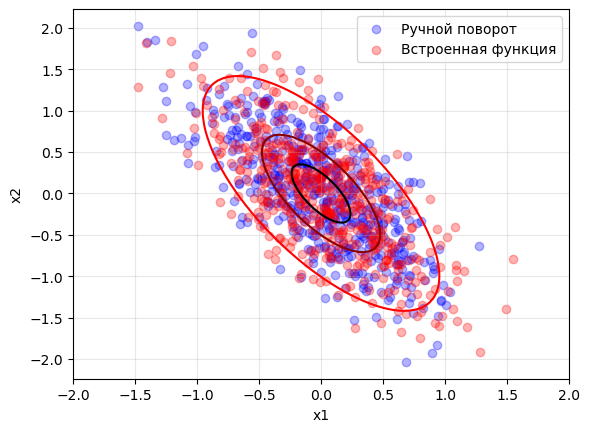

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
M = 500
sigma1 = 0.3
sigma2 = 0.8
mean = np.array([0,0])
cov = np.array([[sigma1**2,0], [0,sigma2**2]])
def generate_gaussian_class(mean, cov, n_samples=250):
    return np.random.multivariate_normal(mean, cov, n_samples)
def rasp(X1, X2, cov):
    X = np.vstack([X1, X2])
    alpha = np.radians(30)
    R = np.array([[np.cos(alpha), -np.sin(alpha)], [np.sin(alpha), np.cos(alpha)]])
    rotation = R @ X.T
    X=rotation.T
    A = np.cov(rotation)
    C = R @ cov @ R.T
    return X, C
X1 = generate_gaussian_class(mean, cov, 250)
X2 = generate_gaussian_class(mean, cov, 250)
X, C1 = rasp(X1, X2, cov)
X_builtin = np.random.multivariate_normal(mean=[0, 0], cov=C1, size=M)
C2=np.cov(X.T)
print(f"Теоретическая матрица ковариации {C1}")
print(f"Выборочная матрица ковариации {C2}")
assert X.shape == (M, 2), "Неверная размерность данных"
assert np.abs(np.cov(X.T)[0, 1]) > 0.1, "Корреляция слишком мала (проверьте поворот)"
assert np.allclose(np.mean(X, axis=0), 0, atol=0.1), "Среднее должно быть около 0"
plt.scatter(X[:,0], X[:,1], alpha=0.3, color='blue', label='Ручной поворот')
plt.scatter(X_builtin[:, 0], X_builtin[:, 1], alpha=0.3, color='red', label='Встроенная функция')
x_grid, y_grid = np.mgrid[-2:2:100j, -2:2:100j]
pos = np.dstack((x_grid, y_grid))
mean = np.array([0.0, 0.0])
density = multivariate_normal(mean, C1).pdf(pos)
rv = multivariate_normal(mean, C1)
pdf_max = rv.pdf(mean)
levels = pdf_max * np.array([
    np.exp(-0.5 * 2**2),    # 2σ - самый низкий уровень (красный)
    np.exp(-0.5 * 1**2),    # 1σ - средний (темно-красный)
    np.exp(-0.5 * 0.5**2),  # 0.5σ - самый высокий (чёрный)
])
plt.contour(x_grid, y_grid, density, levels=levels,
            colors=['red', 'darkred', 'black'], linewidths=1.5)
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Теоретическая матрица ковариации и выборочная близки, с ростом числа точек выборочная оценка стремится к теоретической. На графике облако вытянуто вправо-вниз, а эллипсы равной плотности (0.5σ, 1σ, 2σ) хорошо описывают его форму. Синие точки (ручной поворот) и красные (np.random.multivariate_normal) визуально почти похожи, оба метода генерируют выборку из одного распределения. Код встроенной функции автоматически проверяет ковариационную матрицу на положительную определённость и работает с любой размерностью, быстрее и гибче при изменении параметров.

## Часть 2. Визуализация плотности вероятности (5 баллов)

**Цель:** научиться вычислять и визуализировать PDF многомерного нормального распределения.

1. По данным из пункта 1.1 оцените $ \hat{\mu} $ и $ \hat{C} $ (выборочные).
2. Создайте сетку точек в диапазоне от -2 до 2 по обеим осям.
3. Вычислите плотность вероятности в каждой точке сетки **двумя способами**:
   - С помощью `scipy.stats.multivariate_normal(mean=mu, cov=C).pdf()`.
   - Самостоятельно по формуле (1) из задания (используйте `np.linalg.det` и `np.linalg.inv`).
4. Сравните результаты (максимальная разница должна быть < 1e-10).

**Визуализация:**
- Постройте contour plot с заливкой (используя `plt.contourf`).
- Добавьте линии уровня (contour) с подписями значений.
- Нанесите исходные точки поверх фона.

**Автопроверка:**
```python
# Проверка ручного вычисления
pdf_manual = ... # ваша реализация
pdf_scipy = m.pdf(grid_points)
assert np.allclose(pdf_manual, pdf_scipy, atol=1e-8), "Ручное вычисление отличается от scipy"
```

---

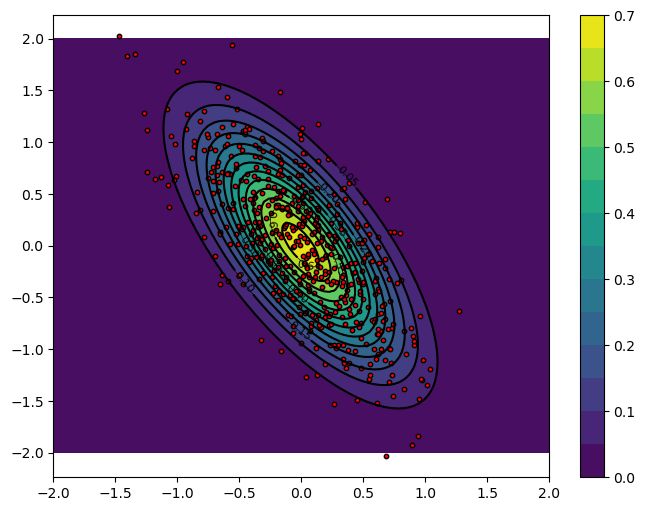

In [4]:
import numpy as np
import scipy
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt
mu_hat = np.mean(X,axis=0)
invC = np.linalg.inv(C2)
detC = np.linalg.det(C2)
norm = 1.0 / np.sqrt((2*np.pi)**2 * detC)
p = scipy.stats.multivariate_normal(mean=mu_hat, cov=C2)
XX, YY = np.meshgrid(np.linspace(-2,2,100),np.linspace(-2,2,100))
grid = np.dstack([XX, YY]).reshape(-1, 2)
diff = grid - mu_hat
m = scipy.stats.multivariate_normal(mean=mu_hat, cov=C2)
pdf_manual = norm * np.exp(-0.5 * np.einsum('...i,ij,...j->...', diff, invC, diff))
pdf_scipy = m.pdf(grid)
assert np.allclose(pdf_manual, pdf_scipy, atol=1e-8), "Ручное вычисление отличается от scipy"
Z = pdf_scipy.reshape(XX.shape)
plt.figure(figsize=(8, 6))
cs = plt.contourf(XX, YY, Z, levels=15, cmap='viridis')
plt.contour(XX, YY, Z, levels=15, colors='k', linewidths=0.5)
plt.clabel(plt.contour(XX, YY, Z, levels=15, colors='k'), inline=True, fontsize=8)
plt.scatter(X[:, 0], X[:, 1], s=10, c='red', edgecolor='k')
plt.colorbar(cs)
plt.show()

Сначала я вычислила $ \hat{\mu} $ и С2, вычислила обратную матрицу и определитель матрицы С2. Вычислила множитель перед экспонентой в формуле, создала сетку из 100 точек от -2 до 2. В ручную вычислила PDF, а затем через scipy. Код прошёл автопроверки и визуализировала это на графике. Визуализация показывает, что оценённое распределение N($ \hat{\mu} $, C2) хорошо описывает данные. Плотность максимальна в центре облака.

## Часть 3. Бинарная классификация через байесовский подход (15 баллов)

**Цель:** визуализировать разделяющую поверхность для двух классов.

### 3.1 Генерация датасета
Создайте два класса (по 300 точек каждый):
- **Класс 0:** $ \mu_0 = (-0.5, 0.5) $, $ C_0 = \begin{bmatrix} 0.2 & 0.1 \\ 0.1 & 0.3 \end{bmatrix} $
- **Класс 1:** $ \mu_1 = (0.5, -0.5) $, $ C_1 = \begin{bmatrix} 0.3 & -0.1 \\ -0.1 & 0.2 \end{bmatrix} $

### 3.2 Визуализация апостериорной вероятности
Для каждой точки сетки вычислите:
$
\Delta(x) = p(x|y=0) \cdot p(y=0) - p(x|y=1) \cdot p(y=1)
$
где $ p(y) $ оценивается как доля объектов класса в выборке.

**Визуализация:**
- Scatter plot точек классов (разными цветами).
- Заливка фона: положительные значения $ \Delta $ — одним цветом (например, синим), отрицательные — другим (красным).
- Линия, где $ \Delta(x) = 0 $ (разделяющая поверхность) — через `plt.contour(..., levels=[0])`.

**Вопрос (ответить текстом):** является ли разделяющая поверхность линейной? Почему?

---

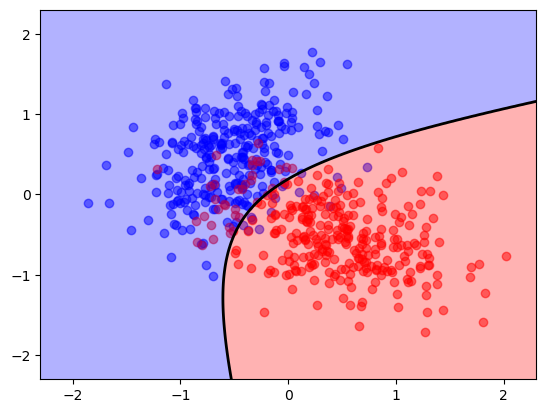

In [5]:
mu0=np.array([-0.5,0.5])
mu1=np.array([0.5,-0.5])
C_0=np.array([[0.2, 0.1], [0.1, 0.3]])
C_1=np.array([[0.3, -0.1], [-0.1, 0.2]])
X_0 = generate_gaussian_class(mu0, C_0, 300)
X_1 = generate_gaussian_class(mu1, C_1, 300)
X_o = np.vstack([X_0,X_1])
y_o = np.hstack([np.zeros(300), np.ones(300)])
p0 = np.mean(y_o == 0)
p1 = np.mean(y_o == 1)
XX, YY = np.meshgrid(np.linspace(-2.3, 2.3, 200), np.linspace(-2.3, 2.3, 200))
grid = np.dstack([XX, YY]).reshape(-1, 2)
pdf0 = multivariate_normal(mu0, C_0).pdf(grid)
pdf1 = multivariate_normal(mu1, C_1).pdf(grid)
delta = pdf0 * p0 - pdf1 * p1
delta_grid = delta.reshape(XX.shape)
plt.scatter(X_0[:, 0], X_0[:, 1], c='blue', alpha=0.5, label='Класс 0')
plt.scatter(X_1[:, 0], X_1[:, 1], c='red',  alpha=0.5, label='Класс 1')
plt.contourf(XX, YY, delta_grid, levels=[delta_grid.min(), 0, delta_grid.max()],
             colors=['red', 'blue'], alpha=0.3)
plt.contour(XX, YY, delta_grid, levels=[0], colors='black', linewidths=2)

Для классов 0 и 1 задаю среднее и ковариация, ковариации классов различны. Сгенерировала 300 точек для каждого класса. Создала сетку 200 на 200 от -2.3 до 2.3, вычислила плотность для каждой сетки. Вычислила по формуле Δ(x) и визуализировала точки и заливку фона. На графике видно облако синих точек (класс 0) в левой верхней части и красных (класс 1) в правой нижней. Фоновая заливка показывает, где больше каких точек, синяя зона соответствует области. Чёрная линия - разделяющая поверхность Δ(x) = 0. Разделяющая линия не является прямой, она изогнута, образуя кривую, потому что в выражении появляются квадратичные по x члены вида xᵀ C_0⁻¹ x и xᵀ C_1⁻¹ x. Если матрицы различны (C_0 ≠ C_1), эти члены не сокращаются, и уравнение Δ(x) = 0 становится квадратичным относительно x.

## Часть 4. Линейный дискриминантный анализ (LDA) (20 баллов)

### 4.1 Теоретический вывод (в тетради)
**Задание:** выведите явное выражение для разделяющей поверхности в случае, когда $ C_0 = C_1 = C $. Покажите, что она линейна. Напишите формулу для весов $ w $ и порога $ b $ в уравнении $ w^T x + b = 0 $.

### 4.2 Реализация класса LDA
Реализуйте класс `MyLDA`, следуя шаблону:

```python
from sklearn.base import BaseEstimator
import numpy as np

class MyLDA(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None      # словарь {class: mean_vector}
        self.priors_ = None     # словарь {class: prior_prob}
        self.cov_ = None        # общая ковариационная матрица (2D массив)
        self.coef_ = None       # вектор весов w
        self.intercept_ = None  # порог b
    
    def fit(self, X, y):
        """
        X: np.array, shape (n_samples, n_features)
        y: np.array, shape (n_samples,)
        """
        # 1. Сохранить уникальные классы
        # 2. Для каждого класса: вычислить mean и prior
        # 3. Вычислить общую ковариационную матрицу (усредненную по классам)
        # 4. Вычислить w и b
        pass
    
    def predict(self, X):
        """Возвращает предсказанные классы для X"""
        pass
    
    def predict_proba(self, X):
        """Возвращает вероятности принадлежности к каждому классу"""
        pass
```

**Указания:**
- Для устойчивости добавьте небольшой регуляризатор к ковариационной матрице: `cov_reg = cov + 1e-6 * np.eye(n_features)`.
- Формула для весов для бинарного случая:
  $
  w = C^{-1} (\mu_1 - \mu_0)
  $
  $
  b = -\frac{1}{2} \mu_0^T C^{-1} \mu_0 + \frac{1}{2} \mu_1^T C^{-1} \mu_1 + \log\frac{p(y=1)}{p(y=0)}
  $

### 4.3 Проверка на синтетике
- Создайте два класса с одинаковой ковариацией $ C = \begin{bmatrix} 1 & 0.5 \\ 0.5 & 1 \end{bmatrix} $, но разными средними.
- Обучите ваш `MyLDA` и сравните предсказания с `sklearn.discriminant_analysis.LinearDiscriminantAnalysis`.
- Визуализируйте разделяющую прямую и точки.

**Автопроверка:**
```python
# Сравнение с sklearn
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
sk_lda = LinearDiscriminantAnalysis().fit(X_train, y_train)
my_lda = MyLDA().fit(X_train, y_train)
assert np.allclose(my_lda.predict(X_test), sk_lda.predict(X_test)), "Предсказания не совпадают"
assert np.abs(my_lda.coef_ @ sk_lda.coef_ - 1) < 1e-6, "Вектора весов сонаправлены, но разной длины"
```

---

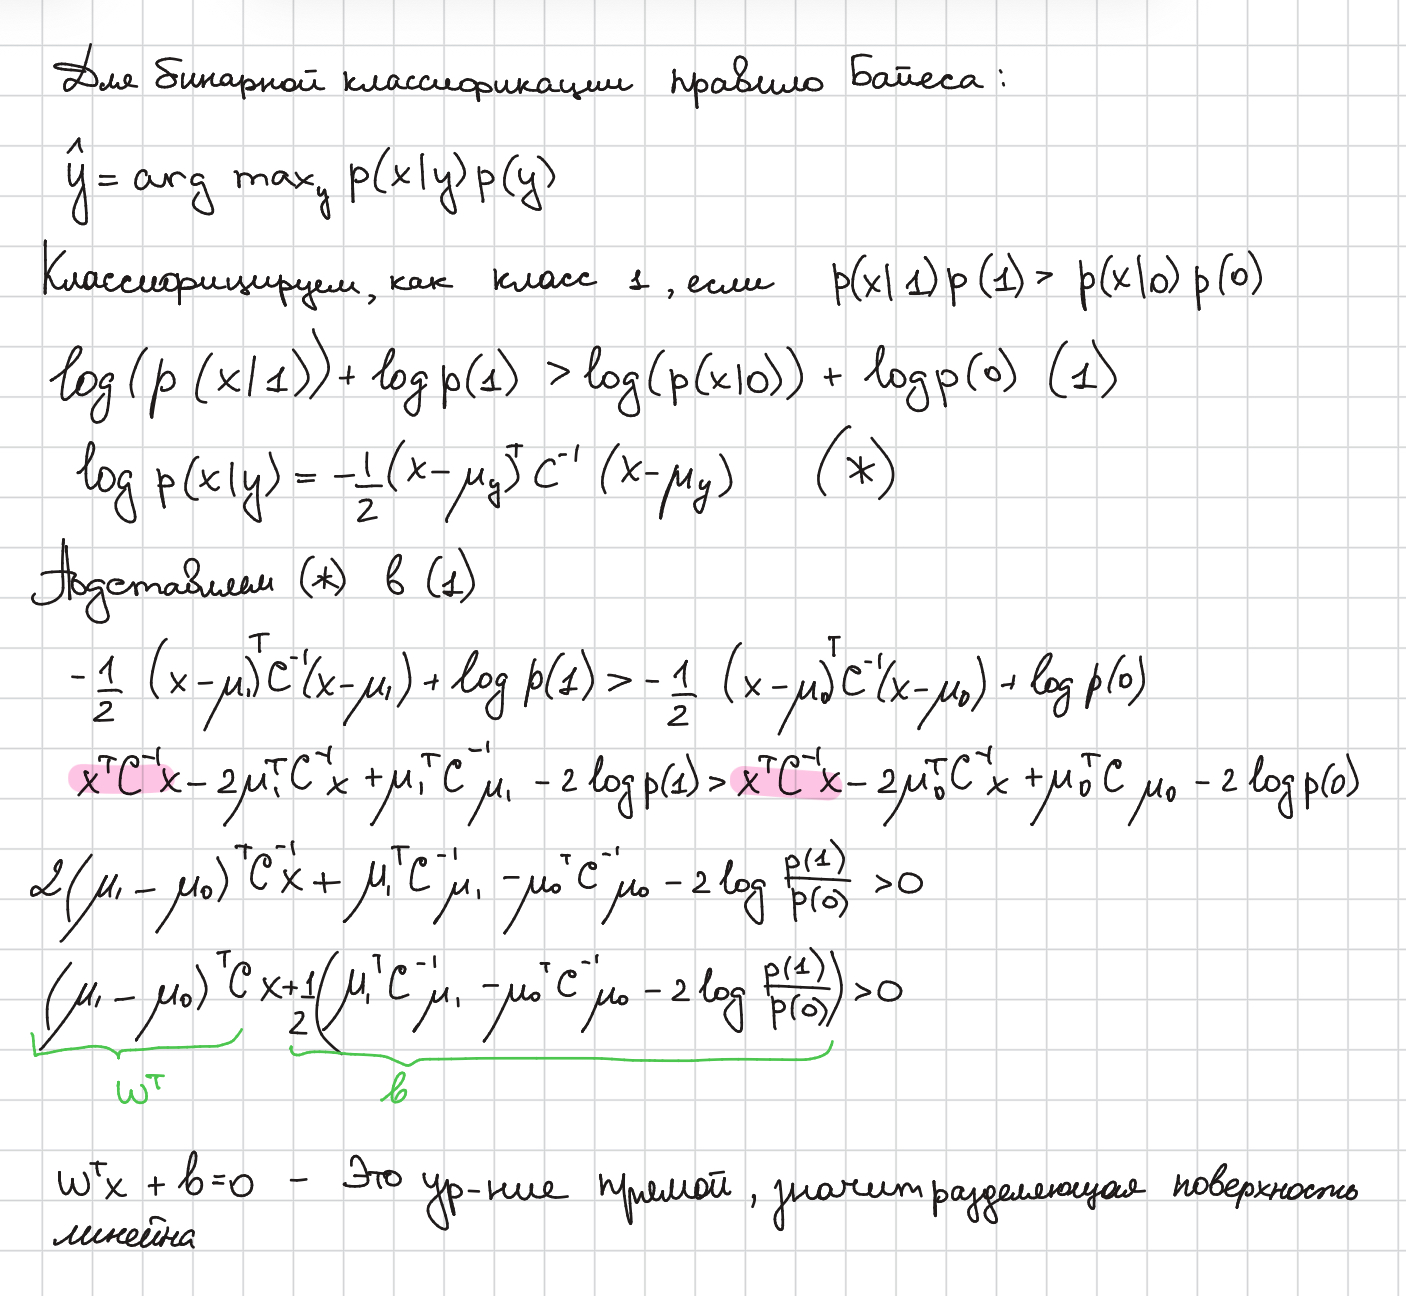

In [13]:
from sklearn.base import BaseEstimator
import numpy as np


class MyLDA(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None      # словарь {class: mean_vector}
        self.priors_ = None     # словарь {class: prior_prob}
        self.cov_ = None        # общая ковариационная матрица (2D массив)
        self.coef_ = None       # вектор весов w
        self.intercept_ = None  # порог b

    def fit(self, X, y):
        """
        X: np.array, shape (n_samples, n_features)
        y: np.array, shape (n_samples,)
        """
        X = np.asarray(X)
        y = np.asarray(y)
        n_samples, n_features = X.shape

        # 1. Сохранить уникальные классы
        self.classes_ = np.unique(y)

        # 2. Для каждого класса: вычислить mean и prior
        self.means_ = {}
        self.priors_ = {}
        for c in self.classes_:
            Xc = X[y == c]
            self.means_[c] = Xc.mean(axis=0)
            self.priors_[c] = Xc.shape[0] / n_samples

        # 3. Вычислить общую (pooled) ковариационную матрицу
        cov = np.zeros((n_features, n_features))
        for c in self.classes_:
            Xc = X[y == c]
            cov += (Xc.shape[0] - 1) * np.cov(Xc.T)
        cov /= (n_samples - len(self.classes_))

        # Регуляризатор для устойчивости
        cov += 1e-6 * np.eye(n_features)
        self.cov_ = cov

        # 4. Вычислить w и b для бинарного случая
        c0, c1 = self.classes_[0], self.classes_[1]
        mu0, mu1 = self.means_[c0], self.means_[c1]
        p0, p1 = self.priors_[c0], self.priors_[c1]

        invC = np.linalg.inv(cov)
        self.coef_ = invC @ (mu1 - mu0)
        self.intercept_ = (
            -0.5 * mu1 @ invC @ mu1
            + 0.5 * mu0 @ invC @ mu0
            + np.log(p1 / p0)
        )
        return self

    def predict(self, X):
        """Возвращает предсказанные классы для X"""
        scores = np.asarray(X) @ self.coef_ + self.intercept_
        return np.where(scores > 0, self.classes_[1], self.classes_[0])

    def predict_proba(self, X):
        """Возвращает вероятности принадлежности к каждому классу"""
        scores = np.asarray(X) @ self.coef_ + self.intercept_
        p1 = 1.0 / (1.0 + np.exp(-scores))
        p0 = 1.0 - p1
        return np.column_stack([p0, p1])

В fit я реализовала приведение X и y к массивам NumPy, сохранение уникальных классов через np.unique, вычисление средних и априорных вероятностей по каждому классу, расчёт общей ковариации как сумма (n_c − 1)·cov(X_c), делённая на (n_samples − K), вычисление весов и порога. По формулам из теории вычислила coef_ и intercept_. Реализовала методы predict и predict_proba, predict применяет np.where(scores > 0, classes_[1], classes_[0]), а predict_proba - сигмоиду к значению дискриминанта и возвращает матрицу [p0, p1].

In [19]:
from sklearn.base import BaseEstimator
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
C_o=np.array([[1, 0.5], [0.5, 1]])
mu0 = np.array([0.0, 0.0])
mu1 = np.array([2.0, 2.0])
n=300
X0 = np.random.multivariate_normal(mu0, C_o, n)
X1 = np.random.multivariate_normal(mu1, C_o, n)
X = np.vstack([X0, X1])
y = np.hstack([np.zeros(n), np.ones(n)])

# Разделение train/test
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=0)

# Мой LDA
my_lda = MyLDA().fit(X_tr, y_tr)
# sklearn LDA
sk_lda = LinearDiscriminantAnalysis().fit(X_tr, y_tr)

# Проверки
print("Мои предсказания:     ", my_lda.predict(X_te)[:10])
print("Предсказания sklearn: ", sk_lda.predict(X_te)[:10])

# Сравнение с sklearn
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
sk_lda = LinearDiscriminantAnalysis().fit(X_tr, y_tr)
my_lda = MyLDA().fit(X_tr, y_tr)
assert np.allclose(my_lda.predict(X_te), sk_lda.predict(X_te)), "Предсказания не совпадают"
cos = (my_lda.coef_ @ sk_lda.coef_.ravel()) / (
    np.linalg.norm(my_lda.coef_) * np.linalg.norm(sk_lda.coef_)
)
assert np.abs(cos - 1) < 1e-6, "Вектора весов не сонаправлены"

Мои предсказания:      [1. 0. 1. 1. 0. 1. 1. 1. 1. 0.]
Предсказания sklearn:  [1. 0. 1. 1. 0. 1. 1. 1. 1. 0.]


Создаю два класса с одиннаковой ковариацией и разными средними (по 300 точек). Далее обучаются две модели на одних и тех же данных. Вывожу первые 10 предсказаний обеих моделей, они совпадают. Автопроверки пройдены. Это значит, что обе модели строят одну и ту же разделяющую прямую, веса могут отличаться длиной, но направление одинаковое, а значит и знак wᵀx + b совпадает, и классификация идентична.

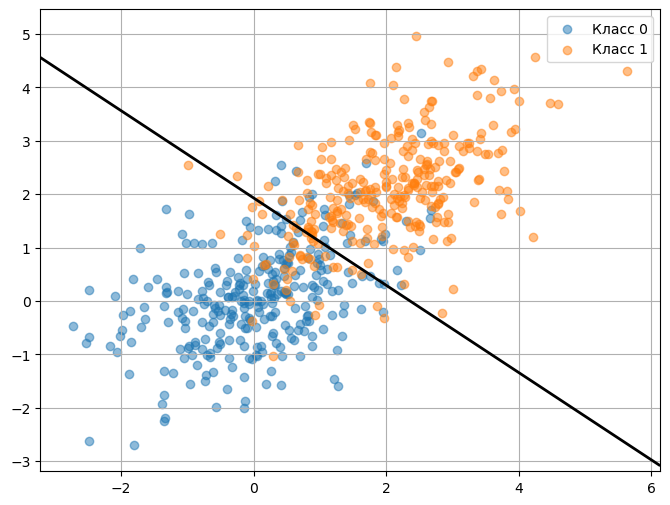

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(X0[:, 0], X0[:, 1], alpha=0.5, label='Класс 0')
plt.scatter(X1[:, 0], X1[:, 1], alpha=0.5, label='Класс 1')

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = grid_points @ my_lda.coef_ + my_lda.intercept_
Z = Z.reshape(xx.shape)

plt.contour(xx, yy, Z, levels=[0], colors='black', linewidths=2)

plt.legend()
plt.grid(True)
plt.show()

Cтрою график с точками обоих классов и разделяющей прямой. Сначала через plt.scatter наносятся точки класса 0 и класса 1. Затем вычисляются границы области, через np.meshgrid строится сетка 100×100 точек, которая преобразуется в массив. Точки класса 0 образуют облако в левой нижней части, класса 1 в правой верхней. Разделяющая прямая проходит между ними. Прямая линейна, потому что при равных ковариациях C₀ = C₁ квадратичные члены сокращаются, и граница становится прямой wᵀx + b = 0. Направление прямой определяется вектором w = C⁻¹(μ₁ − μ₀), который в данном случае смотрит из класса 0 в класс 1. Прямая делит плоскость на две полуплоскости.

## Часть 5. Наивный байесовский классификатор (NB) (20 баллов)

### 5.1 Теоретическое обоснование
**Вопрос:** почему в наивном байесе матрица ковариации диагональная? Как это упрощает вычисление $ p(x|y) $?

### 5.2 Реализация класса NB
Реализуйте класс `MyNB`:

```python
class MyNB(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None      # dict {class: mean_vector}
        self.vars_ = None       # dict {class: variance_vector} (диагональ ковариации)
        self.priors_ = None     # dict {class: prior_prob}
    
    def fit(self, X, y):
        """
        Для каждого класса:
        - Вычислить среднее по каждому признаку
        - Вычислить дисперсию по каждому признаку
        - Вычислить априорную вероятность
        """
        pass
    
    def predict(self, X):
        """Вычисляет логарифм правдоподобия для каждого класса и выбирает максимум"""
        pass
```

**Важно:** используйте **логарифмическое правдоподобие** для численной устойчивости:
$
\log p(y|x) \propto \log p(y) + \sum_i \log p(x_i|y) = \log p(y) - \frac{1}{2}\sum_i \left( \log(2\pi\sigma_{y,i}^2) + \frac{(x_i - \mu_{y,i})^2}{\sigma_{y,i}^2} \right)
$

### 5.3 Сравнение с sklearn
- Сравните ваш `MyNB` с `sklearn.naive_bayes.GaussianNB` на тех же данных.
- Убедитесь, что предсказания совпадают (с точностью до численных погрешностей).

**Автопроверка:**
```python
from sklearn.naive_bayes import GaussianNB
sk_nb = GaussianNB().fit(X_train, y_train)
my_nb = MyNB().fit(X_train, y_train)
assert np.allclose(my_nb.predict(X_test), sk_nb.predict(X_test)), "Предсказания NB не совпадают"
```

---

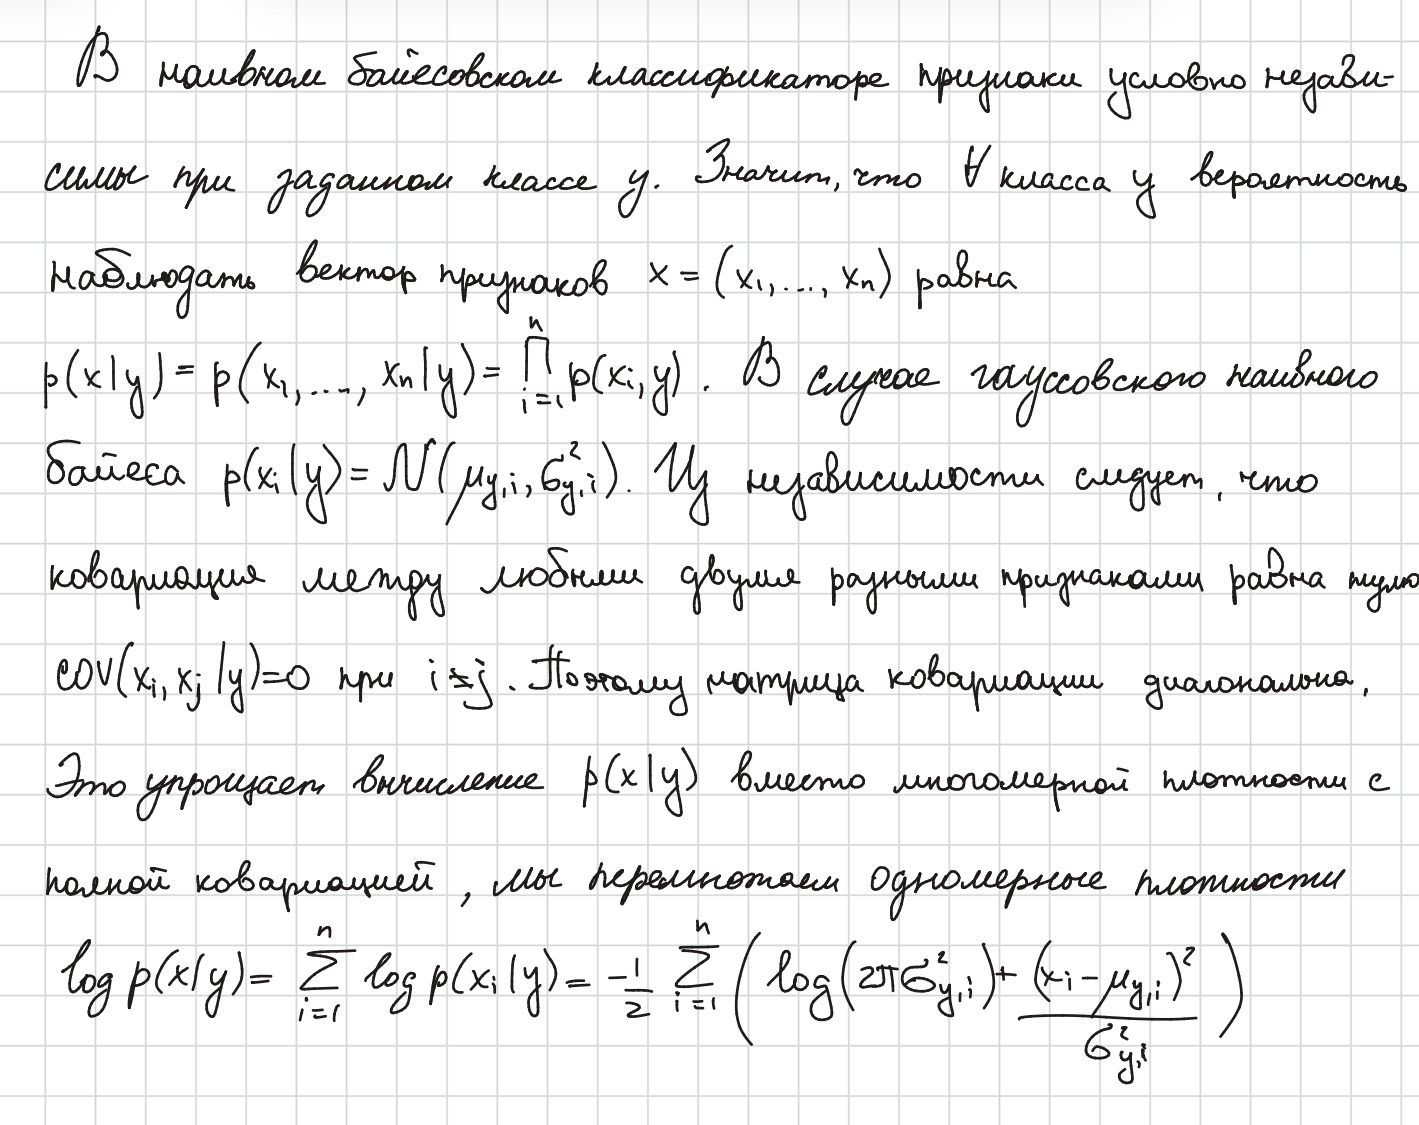

In [21]:
from sklearn.base import BaseEstimator
import numpy as np


class MyNB(BaseEstimator):

    def __init__(self):
        self.classes_ = None
        self.means_ = None
        self.vars_ = None
        self.priors_ = None

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        n_samples, n_features = X.shape

        # 1. Уникальные классы
        self.classes_ = np.unique(y)

        # Словари для параметров
        self.means_ = {}
        self.vars_ = {}
        self.priors_ = {}

        # 2. Оценка параметров для каждого класса
        for cls in self.classes_:

            X_cls = X[y == cls]

            # Среднее каждого признака
            self.means_[cls] = np.mean(
                X_cls,
                axis=0
            )

            # Дисперсия каждого признака
            self.vars_[cls] = np.var(
                X_cls,
                axis=0
            )

            # Априорная вероятность класса
            self.priors_[cls] = (
                len(X_cls) / n_samples
            )

        return self

    def predict(self, X):

        X = np.asarray(X)

        log_probs = []

        for cls in self.classes_:

            mu = self.means_[cls]
            var = self.vars_[cls]
            prior = self.priors_[cls]

            # Защита от деления на ноль
            var = np.maximum(var, 1e-9)

            # log P(y)
            log_prior = np.log(prior)

            # log P(x_i | y)
            log_likelihood = -0.5 * np.sum(
                np.log(2 * np.pi * var)
                + (X - mu) ** 2 / var,
                axis=1
            )

            # log P(y | x) с точностью до общей константы
            log_posterior = (
                log_prior
                + log_likelihood
            )

            log_probs.append(log_posterior)

        # shape: (n_samples, n_classes)
        log_probs = np.column_stack(log_probs)

        # Индекс класса с максимальной вероятностью
        class_indices = np.argmax(
            log_probs,
            axis=1
        )

        return self.classes_[class_indices]

В fit добавила приведение данных к массивам NumPy, поиск уникальных классов через np.unique, инициализация словарей параметров и цикл по классам, в котором для каждого класса вычисляются среднее и дисперсия по каждому признаку отдельно и априорная вероятность как доля класса в выборке. В predict добавила приведение X к массиву, цикл по классам с извлечением параметров mu, var, prior, вычисление логарифма априорной вероятности и логарифма правдоподобия по формуле нормального распределения, итоговый логарифм апостериорной вероятности как их сумма, сбор результатов в матрицу через np.column_stack, выбор класса с максимумом через np.argmax и возвращаю соответствующие метки классов.

In [23]:
from sklearn.naive_bayes import GaussianNB

# sklearn
sk_nb = GaussianNB().fit(
    X_tr,
    y_tr
)

# наша реализация
my_nb = MyNB().fit(
    X_tr,
    y_tr
)

# Предсказания
pred_sk = sk_nb.predict(X_te)
pred_my = my_nb.predict(X_te)

print("Предсказания MyNB:")
print(pred_my)

print("\nПредсказания sklearn:")
print(pred_sk)

print(
    "\nКоличество несовпадений:",
    np.sum(pred_my != pred_sk)
)

assert np.allclose(
    my_nb.predict(X_te),
    sk_nb.predict(X_te)
), "Предсказания NB не совпадают"

print("Предсказания совпадают")

Предсказания MyNB:
[1. 0. 0. 1. 0. 1. 1. 1. 1. 0. 1. 1. 0. 0. 0. 1. 1. 0. 0. 1. 1. 0. 0. 0.
 1. 0. 0. 1. 1. 1. 1. 1. 1. 0. 0. 1. 0. 1. 0. 0. 1. 1. 1. 0. 0. 0. 1. 1.
 1. 1. 0. 0. 0. 0. 0. 1. 1. 0. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 0. 0.
 1. 0. 0. 0. 1. 1. 1. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 1. 1. 0. 0. 1.
 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 1. 1. 1. 1. 1. 0. 1. 0. 1. 1. 1. 1.]

Предсказания sklearn:
[1. 0. 0. 1. 0. 1. 1. 1. 1. 0. 1. 1. 0. 0. 0. 1. 1. 0. 0. 1. 1. 0. 0. 0.
 1. 0. 0. 1. 1. 1. 1. 1. 1. 0. 0. 1. 0. 1. 0. 0. 1. 1. 1. 0. 0. 0. 1. 1.
 1. 1. 0. 0. 0. 0. 0. 1. 1. 0. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 0. 0.
 1. 0. 0. 0. 1. 1. 1. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 1. 1. 0. 0. 1.
 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 1. 1. 1. 1. 1. 0. 1. 0. 1. 1. 1. 1.]

Количество несовпадений: 0
Предсказания совпадают


Сначала обучаю две модели на одинаковых тренировочных данных X_tr, y_tr. Затем обе модели делают предсказания на тестовой выборке X_te, результаты сохраняются в pred_sk и pred_my соответственно. Далее вывожу на экран оба массива предсказаний, чтобы их можно было визуально сравнить, и подсчитываю число несовпадающих позиций через np.sum(pred_my != pred_sk).

## Часть 6. Экспериментальное сравнение LDA и NB (15 баллов)

### 6.1 Генерация датасетов с разной структурой
Создайте **три** различных датасета для бинарной классификации:

1. **Датасет A (LDA-оптимальный):** классы имеют одинаковую ковариацию, но разные средние.
2. **Датасет B (NB-оптимальный):** признаки независимы внутри каждого класса, но ковариации классов разные.
3. **Датасет C (сложный):** признаки коррелированы, ковариации классов разные.

Используйте `sklearn.datasets.make_classification` с параметрами:
- `n_features=10` (для проверки многомерности)
- `n_informative=5`, `n_redundant=2`
- Для датасета C: `flip_y=0.05` (немного шума).

### 6.2 Сравнение моделей
Для каждого датасета:
1. Разделите на train/test (80/20).
2. Обучите `MyLDA`, `MyNB`, а также (для бенчмарка) `sklearn.linear_model.LogisticRegression`.
3. Посчитайте метрики: **Accuracy**, **Precision**, **Recall**, **F1-score** (для каждого класса отдельно и macro-усредненные).
4. Постройте confusion matrix для каждой модели.

### 6.3 Анализ результатов
В Markdown-ячейке напишите **развернутый вывод**:
- На каком датасете LDA превосходит NB? Почему?
- На каком датасете NB работает лучше? Почему?
- Как влияет размерность пространства на обе модели?
- Когда обе модели падают (датасет C) — почему?

**Визуализация:** для каждого датасета постройте столбчатую диаграмму сравнения метрик.

---

In [24]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

np.random.seed(42)

N = 1000
n_features = 10
n_informative = 5
n_redundant = 2

Задают параметры синтетических датасетов: 1000 объектов, 10 признаков всего, 5 информативных и 2 избыточных. Эти параметры дальше будут использоваться для создания трёх датасетов (A, B, C) с разной структурой, чтобы сравнить MyLDA, MyNB и LogisticRegression и понять, какие предположения моделей лучше подходят к каким данным.

In [26]:
# Общая ковариационная матрица
C_A = np.eye(n_features)

# Добавим небольшую корреляцию между некоторыми признаками
for i in range(n_features):
    for j in range(n_features):
        if i != j:
            C_A[i, j] = 0.2 * np.exp(-abs(i - j))

mu_A0 = np.zeros(n_features)
mu_A1 = np.zeros(n_features)

mu_A0[:n_informative] = -1
mu_A1[:n_informative] = 1

X_A0 = np.random.multivariate_normal(mu_A0, C_A, N // 2)
X_A1 = np.random.multivariate_normal(mu_A1, C_A, N // 2)

X_A = np.vstack([X_A0, X_A1])
y_A = np.hstack([
    np.zeros(N // 2, dtype=int),
    np.ones(N // 2, dtype=int)
])

# Перемешиваем
idx = np.random.permutation(N)
X_A = X_A[idx]
y_A = y_A[idx]

print("A:", X_A.shape)

A: (1000, 10)


Сначала строю общую ковариационную матрицу C_A, где на диагонали единицы, а вне диагонали задана небольшая корреляция вида 0.2 * exp(-|i-j|) - то есть близкие по индексу признаки коррелируют сильнее, дальше - слабее. Затем задаются два вектора средних mu_A0 и mu_A1 одинаковой длины n_features, у которых первые n_informative=5 компонент равны -1 и +1 соответственно, а остальные - нули. Далее из многомерного нормального распределения генерируются по N//2 = 500 точек для каждого класса с одинаковой ковариацией C_A, они объединяются в X_A и y_A, после чего индексы перемешиваются через np.random.permutation, чтобы классы не шли подряд. В конце выводится форма массива X_A. Датасет A «LDA-оптимальный», потому что в нём выполнено ключевое допущение LDA: классы имеют одинаковую ковариацию, но разные средние, плэтому на таких данных LDA должен показывать лучшее качество, чем NB, который игнорирует корреляции между признаками.

In [27]:
mu_B0 = np.zeros(n_features)
mu_B1 = np.zeros(n_features)

mu_B0[:n_informative] = -1
mu_B1[:n_informative] = 1

# Диагональные ковариационные матрицы
var_B0 = np.array([0.5, 1.0, 0.7, 1.2, 0.8, 1.0, 0.6, 1.1, 0.9, 1.0])
var_B1 = np.array([1.5, 0.6, 1.3, 0.7, 1.4, 0.8, 1.2, 0.5, 1.6, 0.7])

C_B0 = np.diag(var_B0)
C_B1 = np.diag(var_B1)

X_B0 = np.random.multivariate_normal(mu_B0, C_B0, N // 2)
X_B1 = np.random.multivariate_normal(mu_B1, C_B1, N // 2)

X_B = np.vstack([X_B0, X_B1])
y_B = np.hstack([
    np.zeros(N // 2, dtype=int),
    np.ones(N // 2, dtype=int)
])

idx = np.random.permutation(N)
X_B = X_B[idx]
y_B = y_B[idx]

print("B:", X_B.shape)

B: (1000, 10)


Сначала задаю два вектора средних mu_B0 и mu_B1 длиной n_features, у которых первые n_informative = 5 компонент равны -1 и +1 соответственно, а остальные - нули. Затем задаю два вектора дисперсий var_B0 и var_B1 разной длины и с разными значениями для каждого класса, из которых строятся диагональные ковариационные матрицы C_B0 = np.diag(var_B0) и C_B1 = np.diag(var_B1). Диагональность означает, что признаки внутри каждого класса не коррелируют. При этом ковариации классов разные, что отличает датасет B от датасета A. Далее из двух многомерных нормальных распределений генерируются по N//2 = 500 точек для каждого класса, они объединяются в X_B и y_B, индексы перемешиваются через np.random.permutation, и выводится форма массива. Датасет B - «NB-оптимальный», потому что признаки условно независимы (диагональная ковариация), а ковариации классов разные, поэтому на таких данных NB должен показывать лучшее качество, чем LDA, который использует общую полную ковариацию и «переоценивает» корреляции, которых на самом деле нет.

In [36]:
mu_C0 = np.zeros(n_features)
mu_C1 = np.zeros(n_features)

mu_C0[:n_informative] = -0.7
mu_C1[:n_informative] = 0.7

# Ковариация класса 0
C_C0 = np.eye(n_features)

# Ковариация класса 1
C_C1 = np.eye(n_features)

# Сильные корреляции
for i, j in [(0, 1), (1, 2), (2, 3), (3, 4), (5, 6), (7, 8)]:
    C_C0[i, j] = C_C0[j, i] = 0.6
    C_C1[i, j] = C_C1[j, i] = -0.5

# Дополнительные различия в дисперсиях
C_C0[0, 0] = 1.5
C_C0[1, 1] = 1.2

C_C1[0, 0] = 0.6
C_C1[1, 1] = 1.5

X_C0 = np.random.multivariate_normal(mu_C0, C_C0, N // 2)
X_C1 = np.random.multivariate_normal(mu_C1, C_C1, N // 2)

X_C = np.vstack([X_C0, X_C1])
y_C = np.hstack([
    np.zeros(N // 2, dtype=int),
    np.ones(N // 2, dtype=int)
])

# Добавляем шум flip_y = 0.05
n_flip = int(0.05 * N)
flip_indices = np.random.choice(N, n_flip, replace=False)
y_C[flip_indices] = 1 - y_C[flip_indices]

idx = np.random.permutation(N)
X_C = X_C[idx]
y_C = y_C[idx]

print("C:", X_C.shape)

C: (1000, 10)


Задают средние mu_C0 и mu_C1 (первые 5 признаков равны −0.7 и +0.7), две ковариационные матрицы C_C0 и C_C1 с сильными корреляциями между парами признаков и разными дисперсиями по первым двум признакам. Затем генерируются по 500 точек на класс, объединяются в X_C и y_C, метки 5% объектов случайно инвертируются (шум flip_y = 0.05), индексы перемешиваются. Датасет сложный, потому что нарушены оба допущения моделей, есть корреляции (против NB) и разные ковариации классов (против LDA) плюс шум в метках.

In [37]:
def evaluate_dataset(X, y, dataset_name):
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    models = {
        "LDA": MyLDA(),
        "NB": MyNB(),
        "Logistic Regression": LogisticRegression(max_iter=2000)
    }

    results = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        results[name] = {
            "accuracy": accuracy_score(y_test, y_pred),
            "precision_macro": precision_score(
                y_test, y_pred, average="macro", zero_division=0
            ),
            "recall_macro": recall_score(
                y_test, y_pred, average="macro", zero_division=0
            ),
            "f1_macro": f1_score(
                y_test, y_pred, average="macro", zero_division=0
            ),
            "precision_class_0": precision_score(
                y_test, y_pred, pos_label=0, zero_division=0
            ),
            "precision_class_1": precision_score(
                y_test, y_pred, pos_label=1, zero_division=0
            ),
            "recall_class_0": recall_score(
                y_test, y_pred, pos_label=0, zero_division=0
            ),
            "recall_class_1": recall_score(
                y_test, y_pred, pos_label=1, zero_division=0
            ),
            "f1_class_0": f1_score(
                y_test, y_pred, pos_label=0, zero_division=0
            ),
            "f1_class_1": f1_score(
                y_test, y_pred, pos_label=1, zero_division=0
            )
        }

        print(f"\n{dataset_name} — {name}")
        print("-" * 40)
        print("Accuracy:", results[name]["accuracy"])
        print("Precision:", results[name]["precision_macro"])
        print("Recall:", results[name]["recall_macro"])
        print("F1:", results[name]["f1_macro"])

        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=[0, 1]
        )
        disp.plot()
        plt.title(f"{dataset_name}: {name}")
        plt.show()

    return results

Эта функция проводит полное сравнение трёх моделей на переданном датасете и возвращает словарь с метриками. Сначала данные X, y разделяются на тренировочную и тестовую выборки в пропорции 80/20 с фиксированным random_state=42 и стратификацией по классам, что гарантирует одинаковое соотношение классов в обеих частях и корректность сравнения. Затем создаётся словарь моделей. В цикле по моделям каждая обучается на X_train, делает предсказания на X_test, и для неё вычисляется набор метрик: Accuracy, Precision/Recall/F1 и отдельно precision, recall, F1 для класса 0 и класса 1, чтобы видеть, не «перекашивается» ли модель в сторону одного класса. Далее метрики выводятся в консоль с заголовком вида "Датасет - Модель", после чего строится confusion matrix с подписями классов [0, 1] и заголовком с именем датасета и модели. В конце функция возвращает словарь results со всеми метриками для всех моделей.


A — LDA
----------------------------------------
Accuracy: 0.97
Precision: 0.97
Recall: 0.97
F1: 0.97


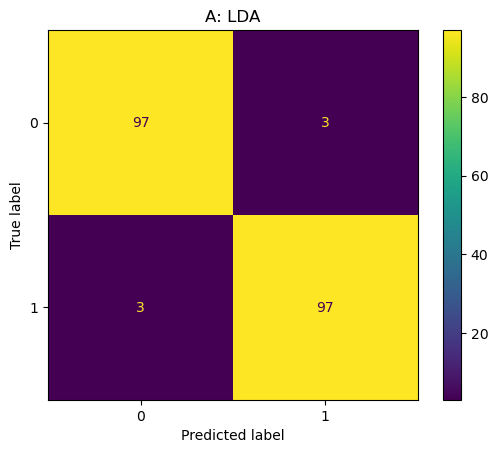


A — NB
----------------------------------------
Accuracy: 0.975
Precision: 0.975047504750475
Recall: 0.975
F1: 0.9749993749843746


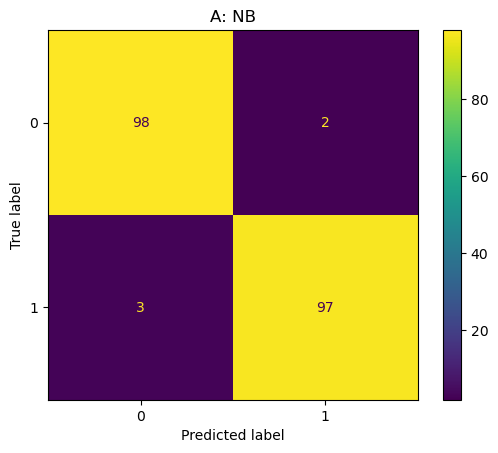


A — Logistic Regression
----------------------------------------
Accuracy: 0.97
Precision: 0.97
Recall: 0.97
F1: 0.97


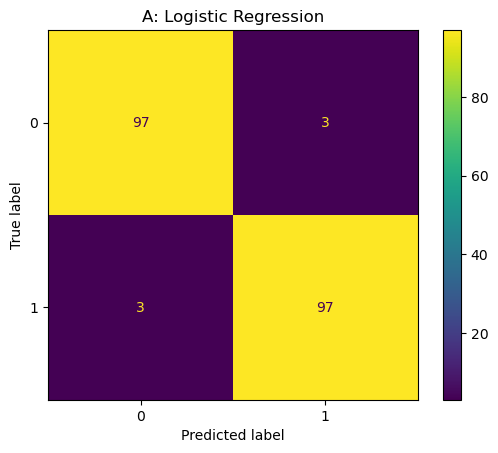


B — LDA
----------------------------------------
Accuracy: 0.99
Precision: 0.9901960784313726
Recall: 0.99
F1: 0.9899989998999901


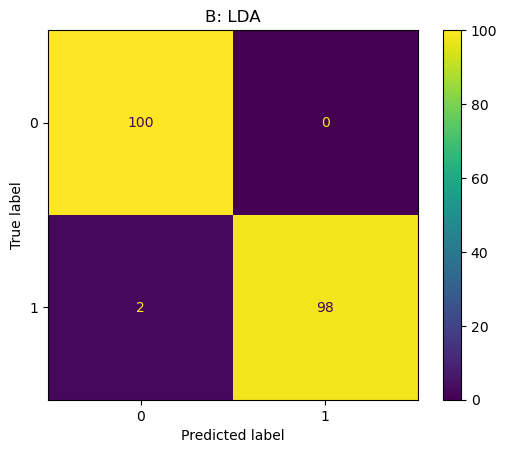


B — NB
----------------------------------------
Accuracy: 0.995
Precision: 0.995049504950495
Recall: 0.995
F1: 0.9949998749968749


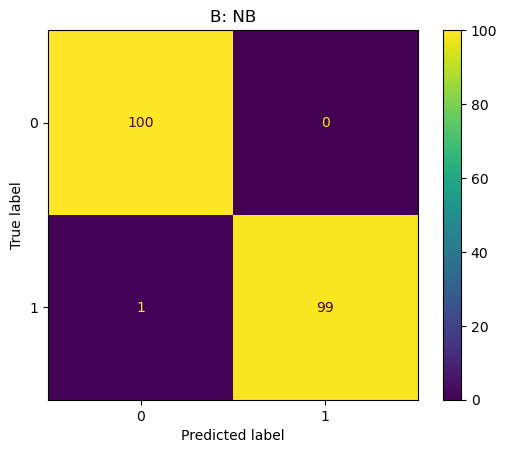


B — Logistic Regression
----------------------------------------
Accuracy: 0.99
Precision: 0.9901960784313726
Recall: 0.99
F1: 0.9899989998999901


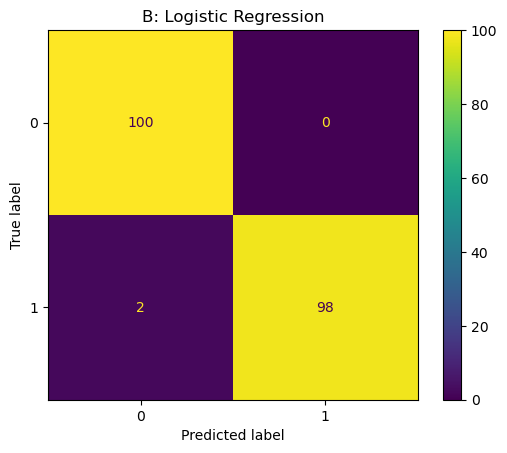


C — LDA
----------------------------------------
Accuracy: 0.905
Precision: 0.9143222506393862
Recall: 0.905
F1: 0.9044626021370208


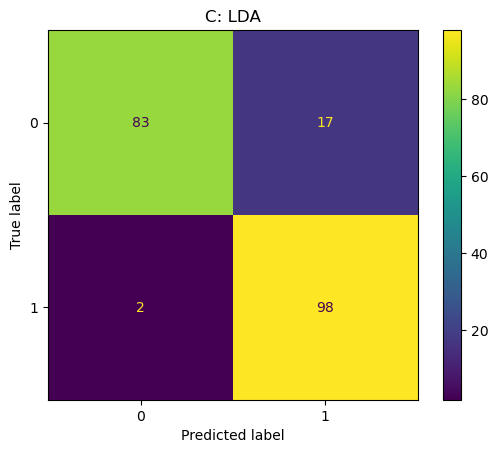


C — NB
----------------------------------------
Accuracy: 0.915
Precision: 0.9221340657105076
Recall: 0.915
F1: 0.9146393512590696


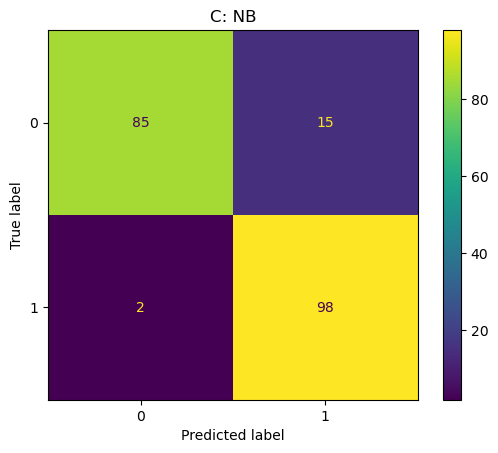


C — Logistic Regression
----------------------------------------
Accuracy: 0.915
Precision: 0.9221340657105076
Recall: 0.915
F1: 0.9146393512590696


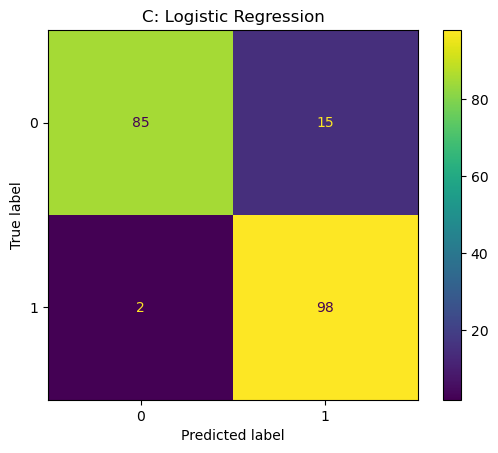

In [39]:
results_A = evaluate_dataset(X_A, y_A, "A")
results_B = evaluate_dataset(X_B, y_B, "B")
results_C = evaluate_dataset(X_C, y_C, "C")

На датасете A все три модели показали близкие результаты: LDA и логистическая регрессия 0 Accuracy ≈ 0.97, а NB - 0.975, поскольку в датасете A выполнено допущение LDA и корреляции между признаками слабые, все три модели справляются хорошо, но NB даже немного выигрывает за счёт меньшего числа параметров и меньшего риска переобучения в многомерном пространстве. На датасете B: LDA и логистическая регрессия дают Accuracy ≈ 0.99, а NB - 0.995, ошибаясь лишь на 1 объекте класса 1, тогда как LDA и логистическая ошибаются на 2. В датасете B признаки условно независимы внутри классов, что является ключевым допущением NB, а ковариации классов разные - то есть NB работает в своих «идеальных» условиях и показывает лучшее качество. На датасете C качество всех моделей заметно падает (Accuracy ≈ 0.905–0.915): здесь нарушены оба допущения (сильные корреляции между признаками против NB и разные ковариации против LDA), плюс добавлен шум flip_y = 5%, из-за чего часть меток неверна в принципе и никакая модель не может их предсказать точно. При этом LDA чуть хуже (0.905), а NB и логистическая регрессия - одинаково 0.915, во всех confusion matrix на датасете C наблюдается асимметрия, модель почти не путает класс 1 (только 2 ошибки), но часто ошибается на классе 0 (15–17 ошибок), что говорит о том, что из-за шума в метках и разной структуры ковариаций модели смещают границу в сторону более «плотного» класса. LDA и NB показывают близкое и высокое качество на данных, соответствующих их допущениям (A и B), причём NB немного выигрывает на B (своём «идеальном» датасете), а на сложном датасете C обе модели деградируют, поскольку ни одна из них не может одновременно учесть и корреляции, и разные ковариации, а шум в метках устанавливает верхнюю границу качества около 0.95.

In [34]:
import pandas as pd

def results_to_dataframe(results):
    rows = []

    for model, metrics in results.items():
        rows.append({
            "Model": model,
            "Accuracy": metrics["accuracy"],
            "Precision": metrics["precision_macro"],
            "Recall": metrics["recall_macro"],
            "F1": metrics["f1_macro"]
        })

    return pd.DataFrame(rows)

df_A = results_to_dataframe(results_A)
df_B = results_to_dataframe(results_B)
df_C = results_to_dataframe(results_C)

print("A")
display(df_A)

print("B")
display(df_B)

print("C")
display(df_C)

A


,Model,Accuracy,Precision,Recall,F1
0,LDA,0.970,0.970000,0.970,0.970000
1,NB,0.975,0.975048,0.975,0.974999
2,Logistic Regression,0.970,0.970000,0.970,0.970000


B


,Model,Accuracy,Precision,Recall,F1
0,LDA,0.990,0.990196,0.990,0.989999
1,NB,0.995,0.995050,0.995,0.995000
2,Logistic Regression,0.990,0.990196,0.990,0.989999


C


,Model,Accuracy,Precision,Recall,F1
0,LDA,0.90,0.905844,0.90,0.899639
1,NB,0.90,0.905844,0.90,0.899639
2,Logistic Regression,0.91,0.912641,0.91,0.909856


Функция results_to_dataframe принимает словарь results, проходит по нему циклом, и для каждой модели формирует одну строку словаря с полями Model, Accuracy, Precision, Recall, F1, извлекая соответствующие значения по ключам accuracy, precision_macro, recall_macro, f1_macro. Затем pd.DataFrame(rows) превращает список таких словарей в таблицу, где столбцы - это метрики, а строки - модели. Далее функция вызывается трижды для результатов на датасетах A, B и C (df_A, df_B, df_C), и каждая таблица выводится на экран через display. В итоге получаются три компактные сводки, по которым удобно визуально сравнивать MyLDA, MyNB и LogisticRegression между собой.

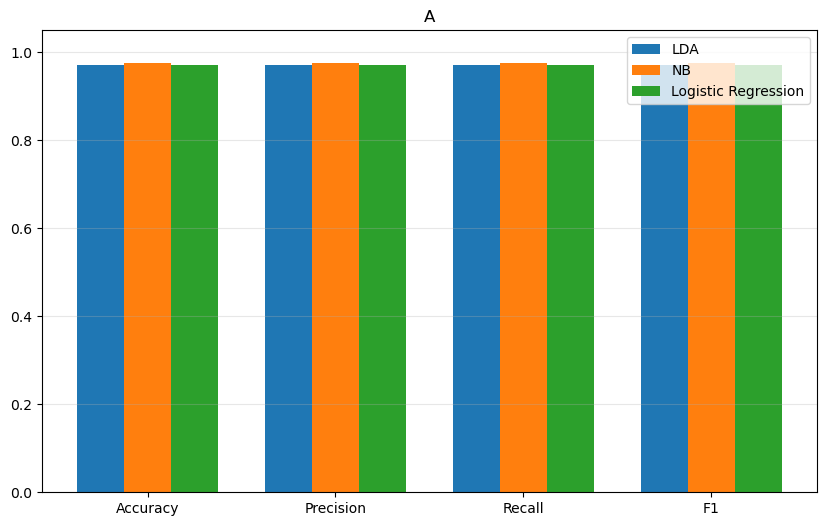

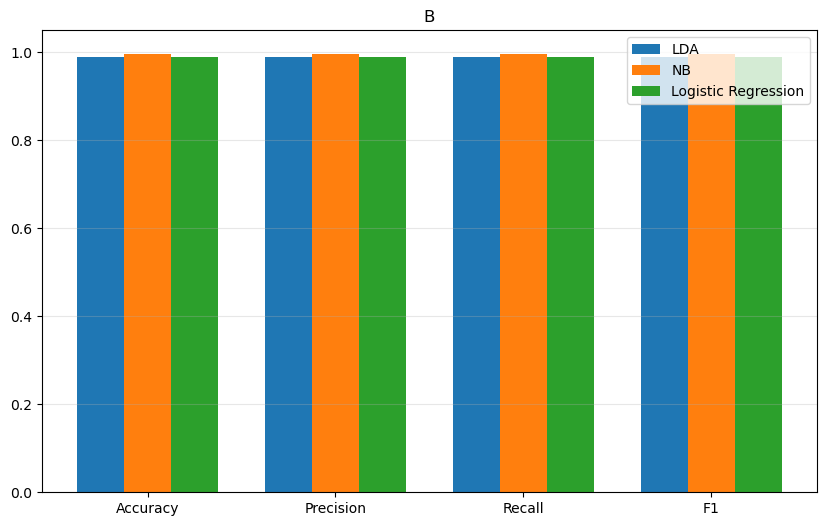

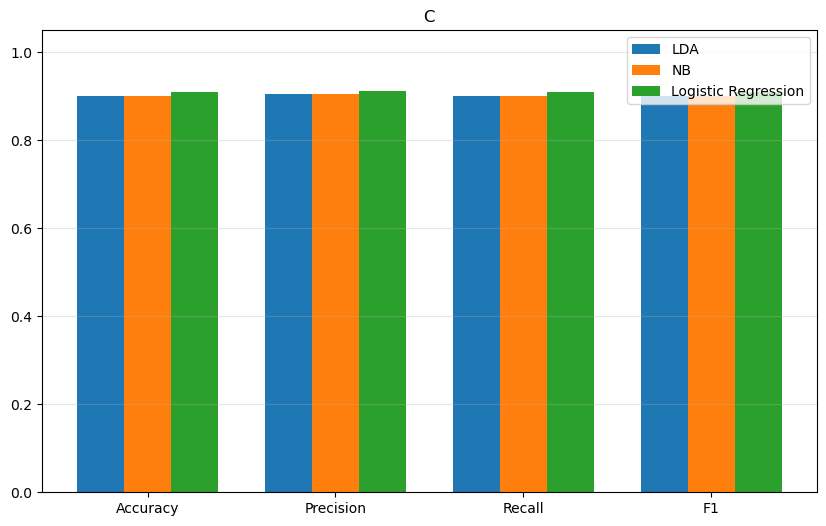

In [35]:
def plot_metrics(results, dataset_name):
    df = results_to_dataframe(results)

    metrics = [
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]

    x = np.arange(len(metrics))
    width = 0.25

    plt.figure(figsize=(10, 6))

    for i, model in enumerate(df["Model"]):
        values = df.loc[df["Model"] == model, metrics].values[0]

        plt.bar(
            x + (i - 1) * width,
            values,
            width,
            label=model
        )

    plt.xticks(x, metrics)
    plt.ylim(0, 1.05)
    plt.title(f"{dataset_name}")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)

    plt.show()

plot_metrics(results_A, "A")
plot_metrics(results_B, "B")
plot_metrics(results_C, "C")

Эта функция строит столбчатую диаграмму для визуального сравнения трёх моделей по четырём метрикам на конкретном датасете. Сначала она превращает переданный словарь results в DataFrame через функцию results_to_dataframe, затем задаёт список метрик для отображения - Accuracy, Precision, Recall, F1. Далее через np.arange(len(metrics)) создаются позиции по оси X. В цикле по моделям из df["Model"] извлекается вектор значений метрик для этой модели, и через plt.bar(x + (i - 1) * width, values, width, label=model) строится группа столбцов. В конце функция вызывается трижды - для результатов на датасетах A, B и C, - так что получаются три диаграммы, на каждой из которых для каждой из четырёх метрик стоят три столбца, что позволяет сразу увидеть, кто выигрывает на данном датасете по всем метрикам одновременно.